# Parallel Trends Check



## Overview



This notebook focuses on validating the parallel-trends assumption for the hospital merger analysis. After constructing the analytic hospital-year panel, we use pre-treatment data to assess whether treated and never-treated hospitals moved similarly before merger exposure.



The goal is to ensure the identifying assumption behind difference-in-differences and event-study specifications is credible before interpreting treatment effects.



## Staggered DiD Design Context

This analysis uses a staggered Difference-in-Differences (staggered DiD) design, where hospitals enter treatment (merger exposure) in different years rather than at a single common time. Each treated hospital is assigned a hospital-specific merger year, and outcomes are evaluated relative to this event time.


Because treatment timing is staggered across hospitals, the parallel-trends assumption is assessed using pre-treatment periods defined relative to each hospital's own merger year. We compare outcome trends for treated hospitals prior to merger with those of never-treated control hospitals observed over the same calendar years.


Because the data span only 2011-2019, we restrict treated hospitals to merger years 2013-2017 and use an event-time window of [-2, +2]. The formal parallel-trends check uses only pre-treatment observations within this restricted window: years_to_merger in [-2, -1].



## Objectives



- Construct a clean pre-period sample with consistent treatment-timing fields

- Restrict treated observations to merger cohorts 2013-2017 and event time [-2, +2]

- Align never-treated controls to the same calendar years for comparability

- Visualize average pre-treatment trends for treated and never-treated groups

- Run a formal joint test of treated-by-year pre-period interactions

- Summarize whether the data provide evidence against parallel pre-trends



## Dataset Description



The notebook uses the hospital analysis panel at the hospital-year level from 01_data/hospital_analysis.csv. Core variables include fiscal_year, treated, years_to_merger, and total_operating_costs.



For scale stability and skew reduction, the primary plotted and modeled outcome is log(1 + total_operating_costs).



## Key Considerations



- Parallel trends concerns similarity in slopes, not equality of baseline levels

- Visual evidence should be interpreted jointly with the formal hypothesis test

- Skewed financial outcomes and outliers motivate log transformation

- Pre-period sample size for treated hospitals affects test precision and power



## Outcome



By the end of this notebook, you get a visual pre-trend diagnostic and a formal interaction-based test result, with a clear conclusion on whether there is statistical evidence against parallel pre-trends at the 5% significance level.

In [10]:
# Imports

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

In [11]:
# Load hospital analysis dataset

cwd = Path.cwd()

project_root = cwd if (cwd / "01_data").exists() else cwd.parent

data_path = project_root / "01_data" / "hospital_analysis.csv"


hospital_analysis = pd.read_csv(data_path)

hospital_analysis.head()

,fiscal_year,RPT_REC_NUM,PRVDR_NUM,NPI,FY_BGN_DT,FY_END_DT,PRVDR_CTRL_TYPE_CD,total_operating_costs,net_patient_revenue,total_charges,...,merger_of_equals,bankruptcy,system_exit,system_split,system_id_yr,any_merger,merger_year,treated,years_to_merger,post_merger
0,2011,1022,271326,NaN,01/01/2011,12/31/2011,2,8661723.0,10224482.0,9125.0,...,0,0,0,0,2246.0,0,NaN,0,NaN,0
1,2011,1501,13025,NaN,01/01/2011,12/31/2011,4,39554420.0,28191835.0,36500.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0
2,2011,1504,103037,NaN,01/01/2011,12/31/2011,4,20242022.0,15733902.0,25550.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0
3,2011,1506,103042,NaN,01/01/2011,12/31/2011,4,26136744.0,21786350.0,29200.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0
4,2011,1507,141990,NaN,01/01/2011,12/31/2011,1,116445.0,486669.0,6205.0,...,0,0,0,0,NaN,0,NaN,0,NaN,0


## Parallel Trends Check



This section tests pre-treatment trend comparability under the restricted staggered DiD design. Treated hospitals are limited to merger-year cohorts 2013-2017, event time is restricted to [-2, +2], and the formal parallel-trends test is run on the pre-treatment subset years_to_merger in [-2, -1], with never-treated controls aligned to the same fiscal years.

In [ ]:
# Build a clean analysis frame and standardize key fields

df = hospital_analysis.copy()

df["fiscal_year"] = pd.to_numeric(df["fiscal_year"], errors="coerce")
df["treated"] = pd.to_numeric(df["treated"], errors="coerce")
df["years_to_merger"] = pd.to_numeric(df["years_to_merger"], errors="coerce")
df["total_operating_costs"] = pd.to_numeric(
    df["total_operating_costs"], errors="coerce"
)
df["merger_year"] = pd.to_numeric(df["merger_year"], errors="coerce")

In [13]:
# Restrict treated units to allowed staggered cohorts and event-time window

allowed_cohort_min, allowed_cohort_max = 2013, 2017
event_window = (-2, 2)
pre_window = (-2, -1)

treated_restricted = df[
    (df["treated"] == 1)
    & (df["merger_year"].between(allowed_cohort_min, allowed_cohort_max))
    & (df["years_to_merger"].between(event_window[0], event_window[1]))
].copy()

# Parallel-trends check uses only the pre-treatment subset from the restricted treated sample.
treated_pre = treated_restricted[
    treated_restricted["years_to_merger"].between(pre_window[0], pre_window[1])
].copy()

# Keep never-treated controls in the same fiscal years as treated pre-period observations.
pre_years = sorted(treated_pre["fiscal_year"].dropna().unique().tolist())
control_pre = df[(df["treated"] == 0) & (df["fiscal_year"].isin(pre_years))].copy()

In [14]:
# Build final pre-period sample and transformed outcome

pre_sample = pd.concat([treated_pre, control_pre], ignore_index=True)
pre_sample = pre_sample.dropna(
    subset=["fiscal_year", "treated", "total_operating_costs"]
)
pre_sample = pre_sample[pre_sample["total_operating_costs"] >= 0].copy()
pre_sample["fiscal_year"] = pre_sample["fiscal_year"].astype(int)
pre_sample["log_total_operating_costs"] = np.log1p(pre_sample["total_operating_costs"])

print(f"Allowed merger-year cohorts: {allowed_cohort_min}-{allowed_cohort_max}")
print(f"Event-time window: [{event_window[0]}, +{event_window[1]}]")
print(
    f"Pre-period window for parallel-trends check: [{pre_window[0]}, {pre_window[1]}]"
)
print(f"Treated pre-period observations: {len(treated_pre):,}")
print(f"Control observations in matched years: {len(control_pre):,}")
print(f"Combined pre-period sample: {len(pre_sample):,}")

Allowed merger-year cohorts: 2013-2017
Event-time window: [-2, +2]
Pre-period window for parallel-trends check: [-2, -1]
Treated pre-period observations: 1,525
Control observations in matched years: 29,744
Combined pre-period sample: 29,743


### Main Parallel Trends Diagnostic

This fiscal-year plot is the primary parallel-trends diagnostic. It compares treated hospitals (pre-treatment observations only, based on each hospital's own merger timing) with never-treated control hospitals in the same calendar years.

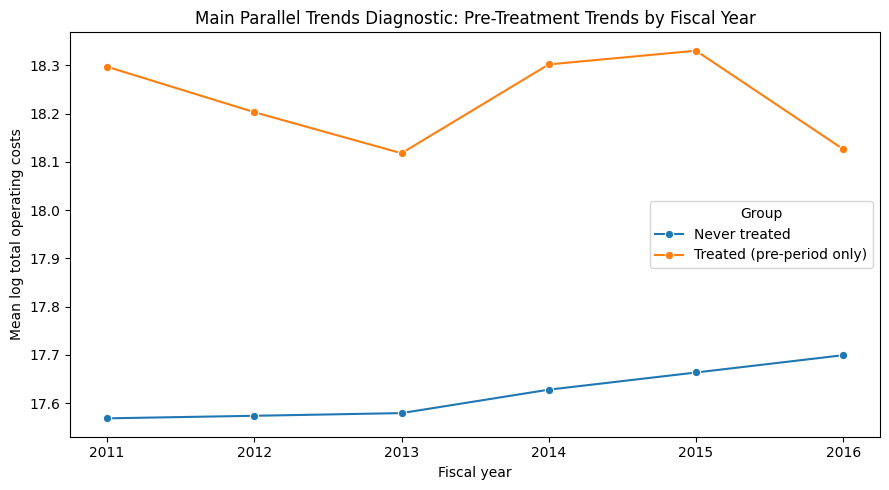

In [19]:
# Visual 1: main parallel-trends diagnostic (calendar-time treated vs never-treated)

# pre_sample already uses treated observations from years_to_merger in [-2, -1].
plot_df = (
    pre_sample.groupby(["fiscal_year", "treated"], as_index=False)[
        "log_total_operating_costs"
    ]
    .mean()
    .sort_values(["fiscal_year", "treated"])
)

plot_df["group"] = plot_df["treated"].map(
    {
        0: "Never treated",
        1: "Treated (pre-period only)",
    }
)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=plot_df,
    x="fiscal_year",
    y="log_total_operating_costs",
    hue="group",
    marker="o",
)

plt.title("Main Parallel Trends Diagnostic: Pre-Treatment Trends by Fiscal Year")
plt.xlabel("Fiscal year")
plt.ylabel("Mean log total operating costs")
plt.xticks(sorted(plot_df["fiscal_year"].unique()))
plt.legend(title="Group")
plt.tight_layout()
plt.show()

### Descriptive Event-Time Visualization (Treated Only)

This event-time plot is descriptive only. It shows how outcomes evolve around merger timing for treated hospitals within [-2, +2], but it does not provide a causal estimate because it does not include a control group.

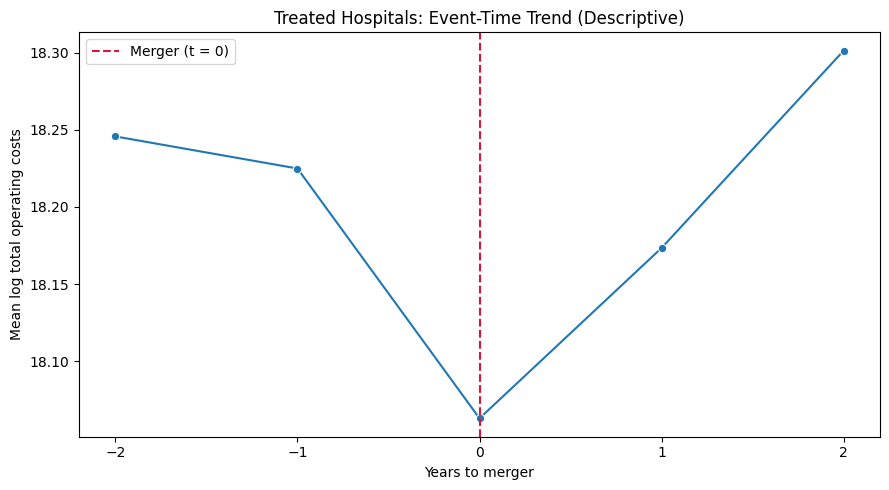

In [20]:
# Visual 2 (descriptive only): treated hospitals by event time in restricted window [-2, +2]

event_df = (
    treated_restricted[["years_to_merger", "total_operating_costs"]].dropna().copy()
)
event_df = event_df[event_df["total_operating_costs"] >= 0].copy()
event_df["years_to_merger"] = event_df["years_to_merger"].astype(int)
event_df["log_total_operating_costs"] = np.log1p(event_df["total_operating_costs"])

event_plot = (
    event_df.groupby("years_to_merger", as_index=False)["log_total_operating_costs"]
    .mean()
    .sort_values("years_to_merger")
)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=event_plot,
    x="years_to_merger",
    y="log_total_operating_costs",
    marker="o",
    color="#1f77b4",
)

plt.axvline(
    0,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="Merger (t = 0)",
)

plt.title("Treated Hospitals: Event-Time Trend (Descriptive)")
plt.xlabel("Years to merger")
plt.ylabel("Mean log total operating costs")
plt.xticks(range(event_window[0], event_window[1] + 1))
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Formal pre-trend test on restricted pre-period sample: treated-by-year interactions jointly zero?

pretrend_model = smf.ols(
    "log_total_operating_costs ~ treated + C(fiscal_year) + treated:C(fiscal_year)",
    data=pre_sample,
).fit(cov_type="HC1")

interaction_terms = [
    term
    for term in pretrend_model.params.index
    if term.startswith("treated:C(fiscal_year)")
]

restriction = " = 0, ".join(interaction_terms) + " = 0"
joint_test = pretrend_model.f_test(restriction)

print("Joint test of treated-by-year interactions (restricted pre-period sample):")
print(f"F-statistic: {float(joint_test.fvalue):.3f}")
print(f"p-value: {float(joint_test.pvalue):.4f}")

if float(joint_test.pvalue) < 0.05:
    print("Conclusion: evidence against parallel pre-trends at the 5% level.")
else:
    print(
        "Conclusion: no statistical evidence against parallel pre-trends at the 5% level."
    )

Joint test of treated-by-year interactions (restricted pre-period sample):
F-statistic: 1.174
p-value: 0.3193
Conclusion: no statistical evidence against parallel pre-trends at the 5% level.


In [18]:
# OLS summary table on restricted pre-period sample

summary_reg = smf.ols(
    "log_total_operating_costs ~ treated + fiscal_year + treated:fiscal_year",
    data=pre_sample,
).fit(cov_type="HC1")

print("Hospital Parallel Trends Test (Restricted Sample)")
print("=" * 66)
print(summary_reg.summary())

interaction_coef = summary_reg.params["treated:fiscal_year"]
interaction_t = summary_reg.tvalues["treated:fiscal_year"]
interaction_p = summary_reg.pvalues["treated:fiscal_year"]

print("\nPre-period slope-difference test (treated x year):")
print(f"Coefficient: {interaction_coef:.6f}")
print(f"t-statistic: {interaction_t:.3f}")
print(f"p-value: {interaction_p:.4f}")

if interaction_p < 0.05:
    print("Conclusion: evidence of differential pre-trends.")
else:
    print("Conclusion: no statistical evidence of differential pre-trends.")

Hospital Parallel Trends Test (Restricted Sample)
                                OLS Regression Results                               
Dep. Variable:     log_total_operating_costs   R-squared:                       0.009
Model:                                   OLS   Adj. R-squared:                  0.009
Method:                        Least Squares   F-statistic:                     130.4
Date:                       Thu, 16 Apr 2026   Prob (F-statistic):           6.35e-84
Time:                               10:51:34   Log-Likelihood:                -54347.
No. Observations:                      29743   AIC:                         1.087e+05
Df Residuals:                          29739   BIC:                         1.087e+05
Df Model:                                  3                                         
Covariance Type:                         HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--

## Summary of Findings



This notebook evaluated the parallel-trends assumption under a restricted staggered DiD design using treated merger-year cohorts 2013-2017 and an event-time window of [-2, +2].



### Visual Evidence

- The fiscal-year pre-period trend plot compares treated hospitals (restricted cohorts) with never-treated controls in matched calendar years.

- The descriptive treated-only event-time plot is limited to [-2, +2] and is used for context, not as the identifying parallel-trends test.



### Statistical Evidence

- Joint pre-trend interaction test (treated-by-year terms) is estimated on the restricted pre-period sample with years_to_merger in [-2, -1].

- Linear slope-difference test (treated \(\times\) year) on the same restricted pre-period sample is consistent with the joint-test evidence.



### Interpretation

The parallel-trends check is based on available pre-treatment observations within the restricted sample implied by the 2011-2019 data window. Across specifications, we evaluate whether there is statistical evidence of differential pre-trends before merger for treated hospitals in the 2013-2017 cohorts relative to never-treated controls observed in the same fiscal years.